# Pollutant Driver Analysis

## Objective

AQI is influenced by multiple pollutants, including particulate matter, nitrogen oxides, sulfur dioxide, and ozone.

This notebook investigates:

* Correlation between pollutants and AQI
* Identification of dominant pollution drivers
* PM2.5 and PM10 relationships with AQI
* Pollutant trends over time
* Relative importance of pollutants

The objective is to determine which pollutants contribute most significantly to air quality deterioration.


## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_aqi.csv")

df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

## Checking Missing Values 


In [2]:
df.isnull().sum().sort_values(ascending=False)

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
Year          0
Month         0
Week          0
dtype: int64

In [4]:
pollutants = [
    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'NH3',
    'CO',
    'SO2',
    'O3',
    'Benzene',
    'Toluene'
]

df[pollutants].describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,24307.0,64.922884,57.286103,0.04,29.185,48.045,77.660,868.66
PM10,24307.0,110.900722,73.416927,0.03,70.525,95.640,123.185,847.41
NO,24307.0,16.838667,21.470627,0.03,5.640,9.710,18.710,390.68
NO2,24307.0,27.677843,22.140963,0.01,11.900,21.670,36.830,362.21
NOx,24307.0,30.649074,28.515569,0.00,13.800,23.170,36.910,378.24
NH3,24307.0,21.879250,22.575016,0.01,11.100,16.270,25.045,352.89
CO,24307.0,1.637772,3.610813,0.00,0.580,0.920,1.410,175.81
SO2,24307.0,13.223079,14.814744,0.01,5.740,9.060,14.420,186.08
O3,24307.0,34.586000,21.206519,0.01,19.535,30.960,45.090,200.41
Benzene,24307.0,3.037687,14.947541,0.00,0.320,1.250,2.740,455.03


## Correlation Analysis

A correlation matrix is used to evaluate relationships between pollutants and AQI.

Strong positive correlations indicate pollutants that are likely major contributors to poor air quality.

In [ ]:
corr = df[
    pollutants + ['AQI']
].corr()

corr['AQI'].sort_values(
    ascending=False
)

AQI        1.000000
PM2.5      0.824359
PM10       0.609305
NO2        0.470379
NOx        0.461208
NO         0.448087
CO         0.393282
SO2        0.334971
O3         0.218827
Toluene    0.193148
NH3        0.139697
Benzene    0.018825
Name: AQI, dtype: float64

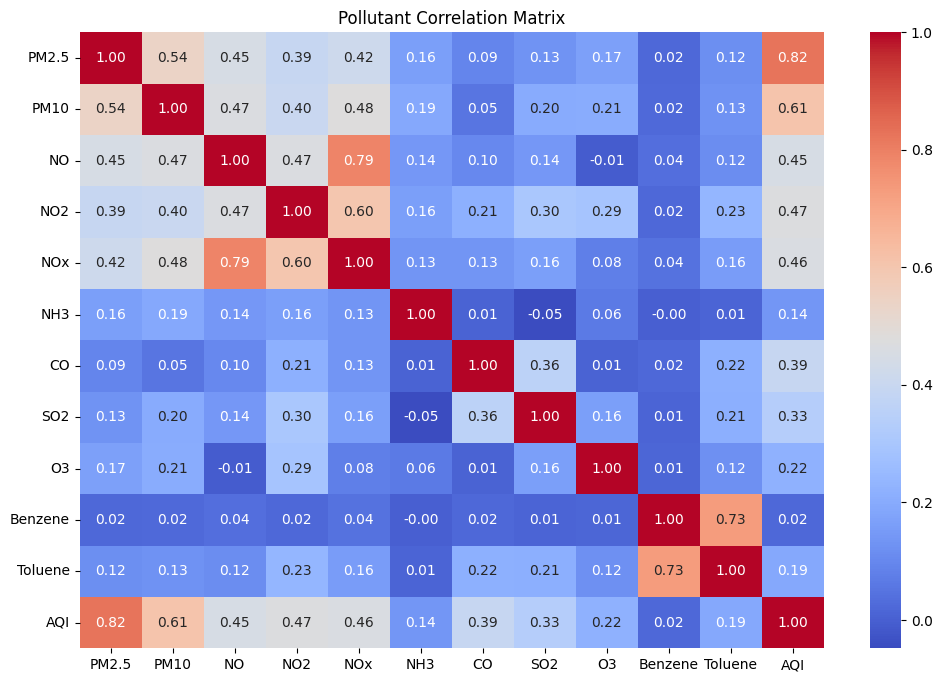

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'Pollutant Correlation Matrix'
)

plt.show()

## AQI vs PM2.5

PM2.5 particles are among the most harmful air pollutants because they can penetrate deep into the respiratory system.

This analysis evaluates the relationship between PM2.5 concentration and AQI.

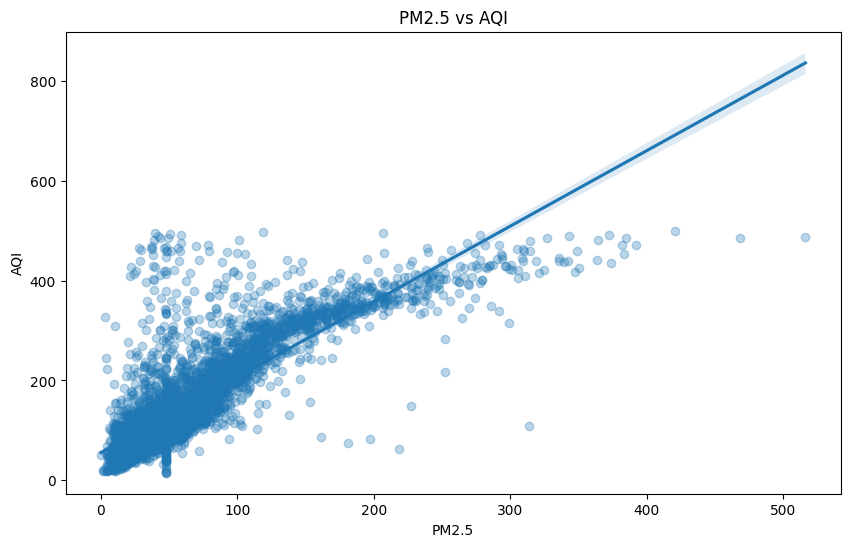

In [ ]:
sample_df = df.sample(
    5000,
    random_state=42
)

plt.figure(figsize=(10,6))

sns.regplot(
    data=sample_df,
    x='PM2.5',
    y='AQI',
    scatter_kws={'alpha':0.3}
)

plt.title('PM2.5 vs AQI')

plt.show()

### Key Observation

A strong positive relationship exists between PM2.5 and AQI.

Higher PM2.5 concentrations are associated with significantly poorer air quality.

## AQI vs PM10

PM10 particles also contribute to air pollution but are generally less harmful than PM2.5.

This analysis evaluates the relationship between PM10 concentration and AQI.

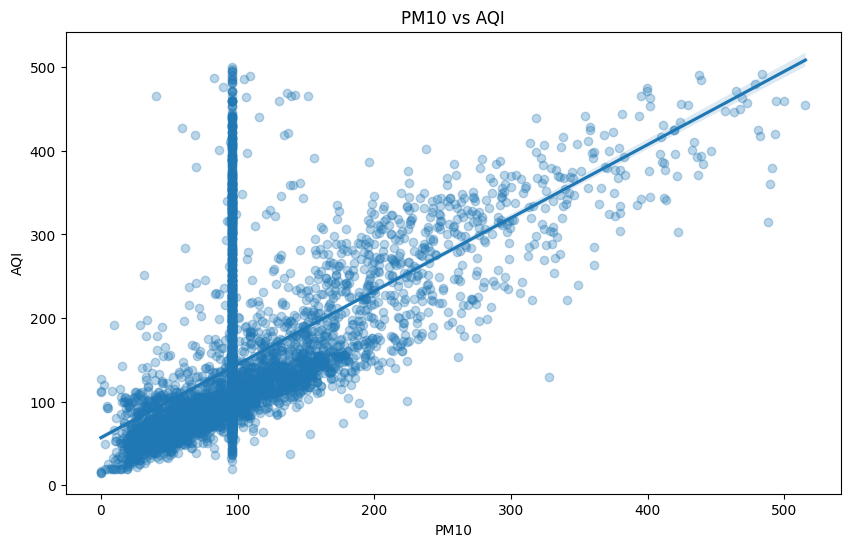

In [ ]:
sample_df = df.sample(
    5000,
    random_state=42
)

plt.figure(figsize=(10,6))

sns.regplot(
    data=sample_df,
    x='PM10',
    y='AQI',
    scatter_kws={'alpha':0.3}
)

plt.title('PM10 vs AQI')

plt.show()

## Long-Term Pollutant Trends

Understanding how pollutant concentrations change over time helps identify whether air quality improvements are driven by reductions in specific pollutants.

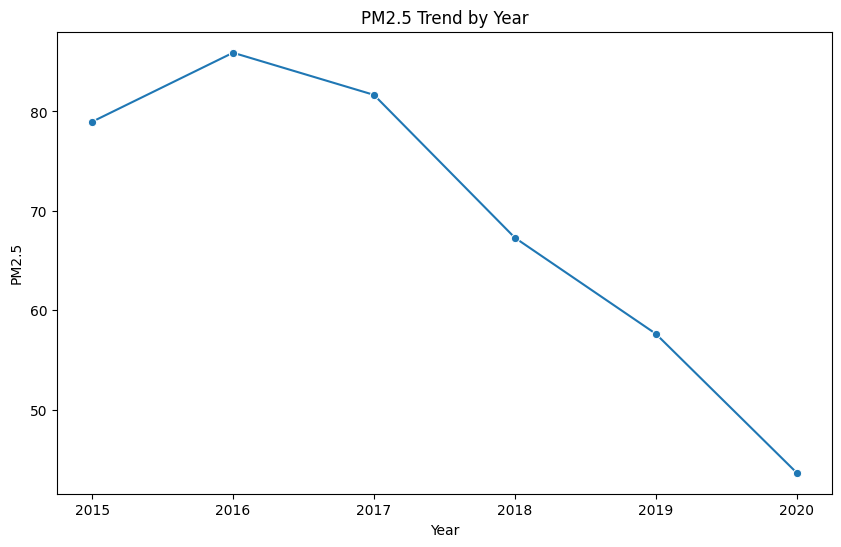

In [ ]:
pm25_year = (
    df.groupby('Year')['PM2.5']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=pm25_year,
    x='Year',
    y='PM2.5',
    marker='o'
)

plt.title(
    'PM2.5 Trend by Year'
)

plt.show()

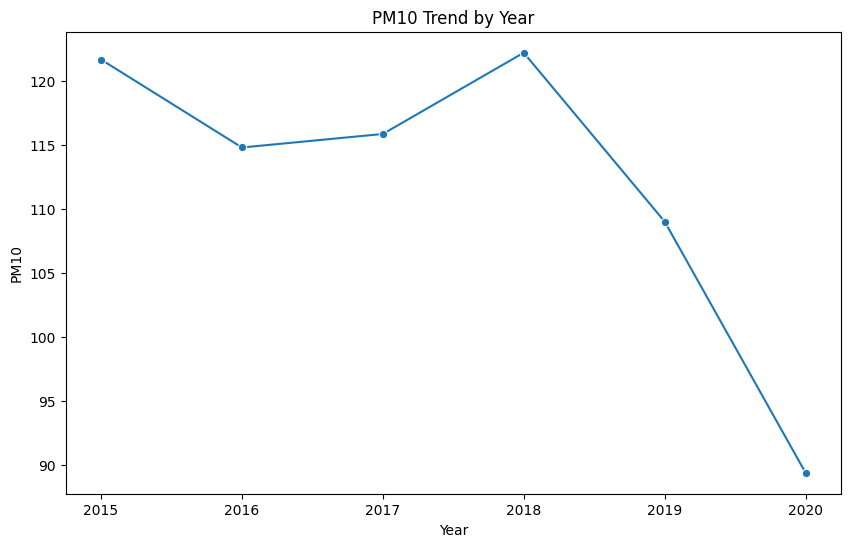

In [ ]:
pm10_year = (
    df.groupby('Year')['PM10']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=pm10_year,
    x='Year',
    y='PM10',
    marker='o'
)

plt.title(
    'PM10 Trend by Year'
)

plt.show()

## Pollutant Importance Ranking

Pollutants are ranked based on their correlation with AQI.

This helps identify the strongest drivers of air pollution.

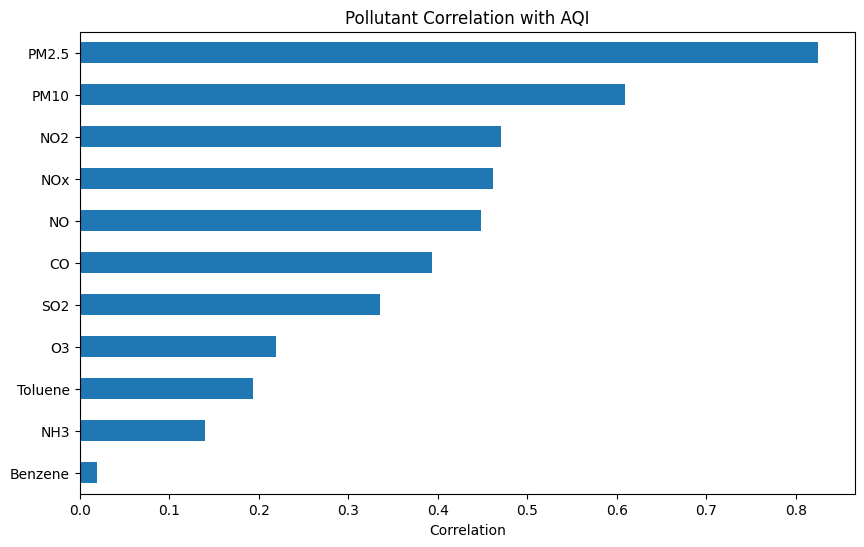

In [ ]:
aqi_corr = (
    corr['AQI']
    .drop('AQI')
    .sort_values()
)

plt.figure(figsize=(10,6))

aqi_corr.plot(kind='barh')

plt.title(
    'Pollutant Correlation with AQI'
)

plt.xlabel('Correlation')

plt.show()

# Key Findings

1. PM2.5 demonstrated the strongest relationship with AQI.
2. PM10 also exhibited a strong positive correlation with AQI.
3. Several gaseous pollutants showed moderate relationships with AQI.
4. Particulate matter emerged as the dominant contributor to poor air quality.
5. Targeting PM2.5 reductions could significantly improve air quality outcomes.

## Conclusion

The analysis highlights particulate matter, especially PM2.5, as the primary driver of AQI variation. Pollution control strategies focused on reducing particulate emissions are likely to yield the greatest environmental benefits.